In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

from pathlib import Path

In [3]:
REPO_ROOT = Path.cwd().resolve().parent

In [4]:
df = pd.read_csv(REPO_ROOT / "data" / "dengue-cases.csv")
df.head()

,month_name,year,region,cases,deaths,month,date
0,January,2016,Region I,705,1,1,2016-01-01
1,February,2016,Region I,374,0,2,2016-02-01
2,March,2016,Region I,276,0,3,2016-03-01
3,April,2016,Region I,240,2,4,2016-04-01
4,May,2016,Region I,243,1,5,2016-05-01


In [5]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [6]:
df = df.sort_values(['region', 'date'])

In [7]:
df['cases_lag1'] = df.groupby('region')['cases'].shift(1)

In [8]:
df_model = df.dropna(subset=['cases_lag1'])

In [9]:
feature_cols = ['year', 'month', 'cases_lag1']
X = df_model[feature_cols]
y = df_model['cases']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 390.1313507462687


In [12]:
import joblib
joblib.dump(model, "../backend/model.joblib")
joblib.dump(feature_cols, "../backend/feature_cols.joblib")

['../backend/feature_cols.joblib']

In [13]:
df_model = df.copy()
print(df_model['cases'].describe())

count     1020.000000
mean      1124.926471
std       1662.608878
min         10.000000
25%        247.750000
50%        582.500000
75%       1284.250000
max      21658.000000
Name: cases, dtype: float64


In [14]:
mae = 390.1313507462687
mean_cases = df_model['cases'].mean()

rel_error = mae / mean_cases
print("Relative MAE:", rel_error)

Relative MAE: 0.3468060899502748


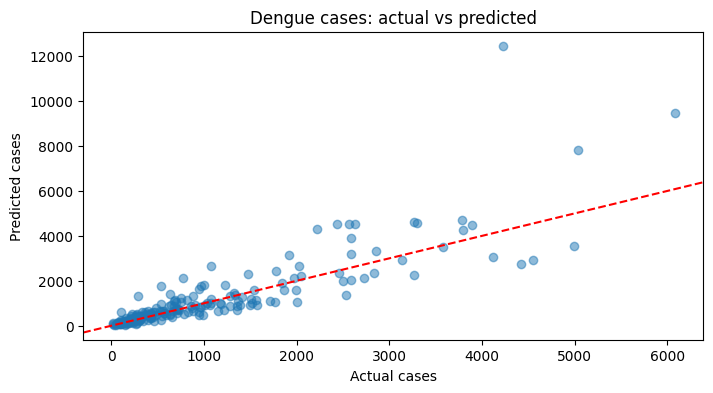

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual cases")
plt.ylabel("Predicted cases")
plt.title("Dengue cases: actual vs predicted")
plt.axline((0, 0), slope=1, color="red", linestyle="--")
plt.show()
